In [3]:
!pip install sklearn-genetic-opt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.9 MB/s eta 0:00:00


In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score

data = load_digits()

n_samples = len(data.images)
X = data.images.reshape((n_samples, -1))
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7)

clf = RandomForestClassifier()

La sección siguiente se realiza balblabalblabl

In [4]:
from sklearn_genetic import GASearchCV
from sklearn_genetic.space import Continuous, Categorical, Integer
from sklearn_genetic.plots import plot_fitness_evolution, plot_search_space
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

param_grid = {'min_weight_fraction_leaf': Continuous(0.01, 0.5, distribution='log-uniform'),
              'bootstrap': Categorical([True, False]),
              'max_depth': Integer(2, 30),
              'max_leaf_nodes': Integer(2, 35),
              'n_estimators': Integer(100, 300)}

cv = StratifiedKFold(n_splits=3, shuffle=True)

evolved_estimator = GASearchCV(estimator=clf,
                               cv=cv,
                               scoring='accuracy',
                               population_size=10,
                               generations=35,
                               tournament_size=3,
                               elitism=True,
                               crossover_probability=0.8,
                               mutation_probability=0.1,
                               param_grid=param_grid,
                               criteria='max',
                               algorithm='eaMuPlusLambda',
                               n_jobs=-1,
                               verbose=True,
                               keep_top_k=4)

In [5]:
evolved_estimator.fit(X_train,y_train)
y_predicy_ga = evolved_estimator.predict(X_test)
accuracy_score(y_test,y_predicy_ga)

gen	nevals	fitness	fitness_std	fitness_max	fitness_min
0  	10    	0.74453	0.108719   	0.916532   	0.543503   
1  	15    	0.861233	0.0363358  	0.916532   	0.79042    
2  	15    	0.900012	0.0209432  	0.916532   	0.862735   
3  	19    	0.917821	0.00853352 	0.935009   	0.899814   
4  	16    	0.921341	0.00758617 	0.935009   	0.916532   
5  	17    	0.919854	0.0076577  	0.935009   	0.912797   
6  	18    	0.925771	0.00923857 	0.935009   	0.916532   
7  	17    	0.933162	0.00554314 	0.935009   	0.916532   
8  	15    	0.935009	2.22045e-16	0.935009   	0.935009   
9  	20    	0.935009	2.22045e-16	0.935009   	0.935009   
10 	19    	0.935009	2.22045e-16	0.935009   	0.935009   
11 	20    	0.935009	2.22045e-16	0.935009   	0.935009   
12 	17    	0.935009	2.22045e-16	0.935009   	0.935009   
13 	17    	0.935009	2.22045e-16	0.935009   	0.935009   
14 	19    	0.935009	2.22045e-16	0.935009   	0.935009   
15 	19    	0.935009	2.22045e-16	0.935009   	0.935009   
16 	20    	0.935009	2.22045e-16	0.935009   	0.9350

0.9443561208267091

/usr/local/lib/python3.12/dist-packages/sklearn_genetic/plots.py:48: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.lineplot(x=range(len(estimator)), y=fitness_history, markers=True, palette=palette)


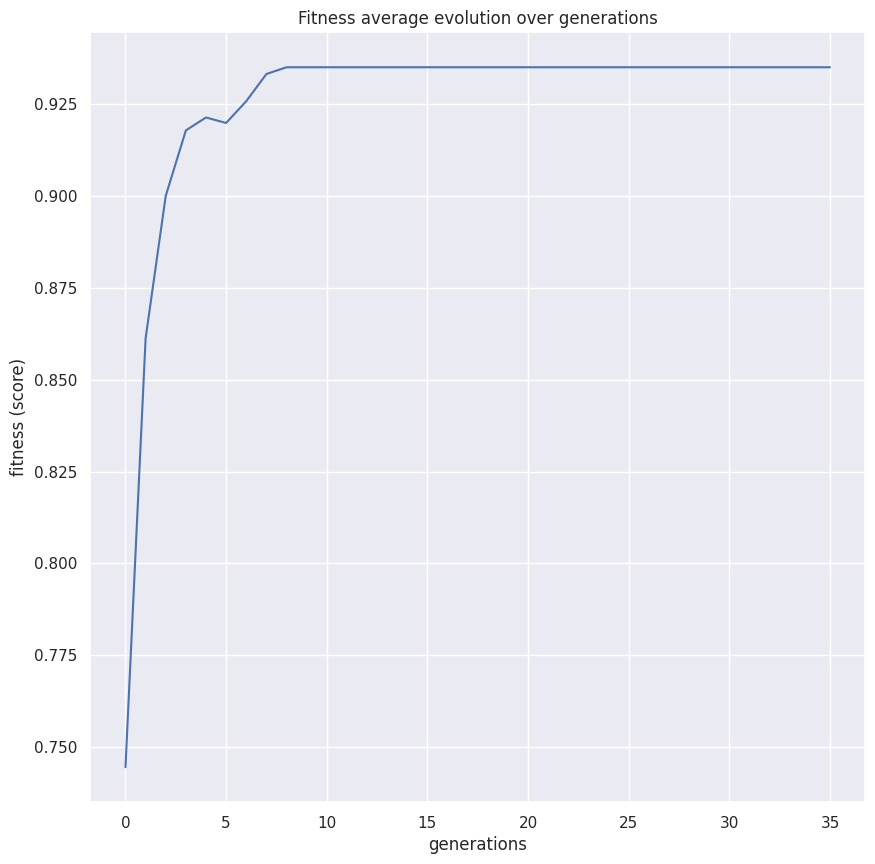

In [6]:
plot_fitness_evolution(evolved_estimator)
plt.show()

Dentro del machine learning existen muchos tipos de algoritmos o programas los cuales sirven para organizar datos de entrada y otorgarles una categoría o etiqueta predefinida, lo cual aporta al programa: la capacidad de tomar decisiones categóricas, además de la identificación y predicción de datos nuevos.
Con este contexto, el objetivo del código presentado en este archivo es encontrar la mejor configuración para un modelo de clasificación llamado Random Forest, para esto, se usó un algoritmo basado en la evolución biológica.
La explicación se divide en los siguientes puntos:

1. Instalación de la biblioteca sklearn-genetic-opt
En primera instancia, se instala la librería faltante (sklearn-genetic-opt). Esta biblioteca permite optimizar los hiperparámetros de los modelos de Machine Learning de scikit-learn utilizando algoritmos genéticos. Luego se importan las herramientas necesarias para el desarrollo.
2. Carga y Preparación de Datos
•	Carga de datos: Aquí es donde se carga un conjunto de datos de imágenes con la línea data = load_digits().
•	Preprocesamiento: Las imágenes cargadas son convertidas en filas de números para que el programa pueda leerlos y así entrenarse.
•	Etiquetar: Se le asigna la etiqueta o valor correcto a cada imagen, lo que indica su respectiva respuesta correcta.
•	División de datos: Los datos son separados en 2 grupos: la mayor cantidad para que el modelo se entrene y aprenda, y el resto para pruebas y evaluar el rendimiento final.
3. Definición y Optimización del Modelo
•	Definición de modelo base: Se inicializa el modelo Random Forest o árboles de decisión para clasificar cada dato (como un diagrama de flujo con decisiones de sí o no).
•	Selección y configuración: Se configura el modelo utilizando un "diccionario" para definir los ajustes. Posteriormente, las líneas de evolved_estimator buscan los mejores ajustes. Se seleccionan 10 modelos del Random Forest, se mide su aptitud, y el proceso se realiza 35 veces. Con estos datos, se cruzan y aplican pequeñas "mutaciones" para asegurarse que solo las mejores configuraciones pasarán a la siguiente generación.
4. Entrenamiento y Evaluación Final
•	Entrenamiento y evaluación final: Se entrena el Random Forest con la mejor configuración encontrada después de las 35 generaciones. Luego se busca que el programa califique los datos de prueba, que no habían sido vistos antes, ayudando a las predicciones. Finalmente, mide la precisión del modelo, indicando el porcentaje de datos que clasificó correctamente.
•	Visualización de datos: La línea de plt.show muestra un gráfico que demuestra cómo el modelo fue mejorando la precisión a lo largo de las 35 generaciones evolutivas.
